<a href="https://colab.research.google.com/github/mahbub19601/creditcardfraudDetection/blob/main/creeditcardfrauddeteection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


Using Colab cache for faster access to the 'creditcardfraud' dataset.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962



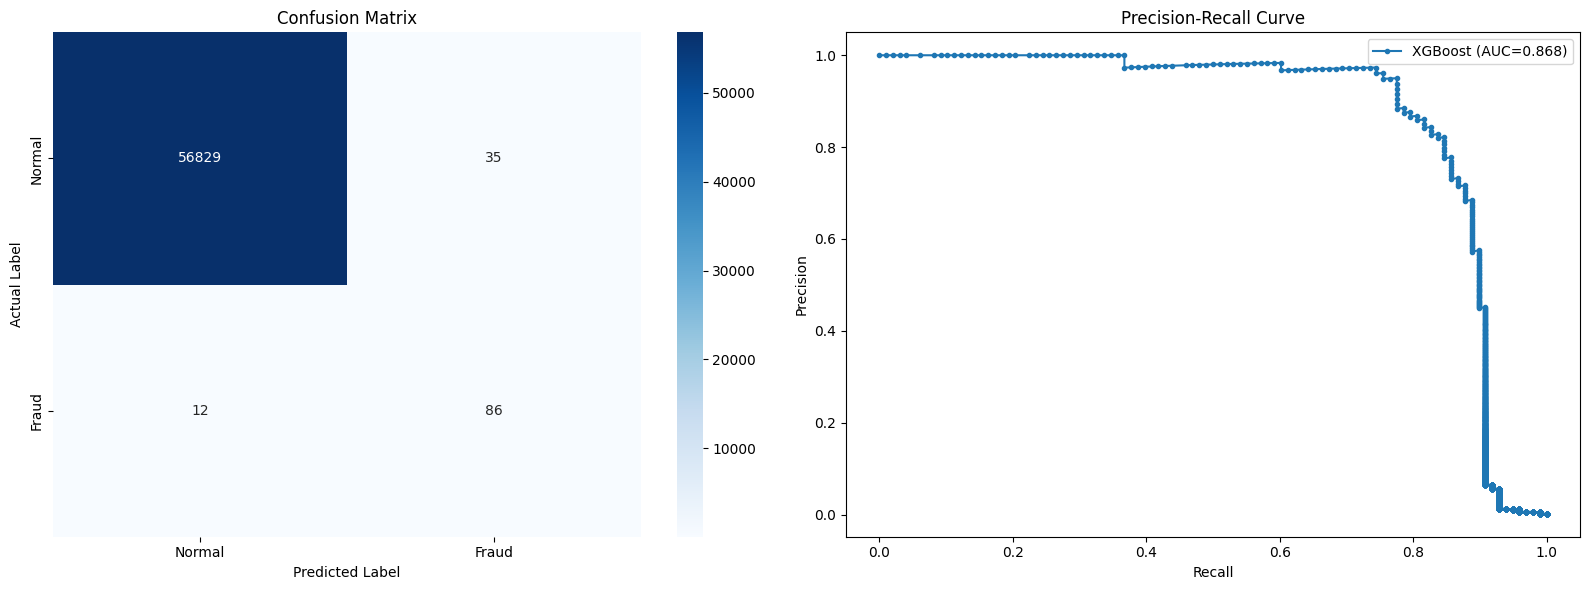

In [ ]:
import os
import logging
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, average_precision_score,
                             confusion_matrix, precision_recall_curve, auc)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

# Configure Professional Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class FraudDetectionSystem:
    """
    End-to-end pipeline for Credit Card Fraud Detection using XGBoost and SMOTE.
    Designed for high-imbalance scenarios.
    """

    def __init__(self, random_state: int = 42):
        self.random_state = random_state
        self.pipeline = None
        self.model_path = "fraud_detection_model.joblib"

    def load_data(self) -> pd.DataFrame:
        """Downloads and loads dataset from KaggleHub."""
        try:
            logger.info("Initiating dataset download via KaggleHub...")
            path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
            csv_path = os.path.join(path, "creditcard.csv")
            df = pd.read_csv(csv_path)
            logger.info(f"Dataset loaded successfully. Shape: {df.shape}")
            return df
        except Exception as e:
            logger.error(f"Failed to load data: {e}")
            raise

    def preprocess(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Scales numerical features and separates target variable.
        """
        logger.info("Preprocessing data...")

        # Robust Scaling for 'Amount' to handle outliers
        scaler = StandardScaler()
        df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
        df = df.drop(['Time', 'Amount'], axis=1)

        X = df.drop('Class', axis=1)
        y = df['Class']

        return X, y

    def build_pipeline(self):
        """
        Constructs an imbalanced-learn pipeline.
        Step 1: SMOTE (Oversampling) - Only applies to training data during fit.
        Step 2: XGBoost Classifier - The estimator.
        """
        self.pipeline = ImbPipeline([
            ('sampler', SMOTE(random_state=self.random_state)),
            ('classifier', xgb.XGBClassifier(
                n_estimators=200,
                max_depth=10,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=self.random_state,
                n_jobs=-1,
                eval_metric='logloss',
                # 'scale_pos_weight' can also be used, but we are using SMOTE here.
                tree_method='hist'  # Optimized for speed
            ))
        ])
        logger.info("ML Pipeline constructed successfully.")

    def train(self, X_train: pd.DataFrame, y_train: pd.Series):
        """Trains the pipeline."""
        if not self.pipeline:
            self.build_pipeline()

        logger.info("Starting model training (SMOTE + XGBoost)...")
        self.pipeline.fit(X_train, y_train)
        logger.info("Training completed.")

    def evaluate(self, X_test: pd.DataFrame, y_test: pd.Series):
        """
        Performs comprehensive evaluation: Classification Report, Confusion Matrix, and PR-AUC.
        """
        logger.info("Evaluating model performance...")
        y_pred = self.pipeline.predict(X_test)
        y_probs = self.pipeline.predict_proba(X_test)[:, 1]

        # 1. Text Report
        print("\n" + "="*40)
        print("CLASSIFICATION REPORT")
        print("="*40)
        print(classification_report(y_test, y_pred))

        # 2. AUPRC Score
        auprc = average_precision_score(y_test, y_probs)
        logger.info(f"Test Set AUPRC: {auprc:.4f}")

        # 3. Visualizations
        self._plot_evaluation(y_test, y_pred, y_probs)

    def _plot_evaluation(self, y_test, y_pred, y_probs):
        """Helper method to plot Confusion Matrix and Precision-Recall Curve."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
        ax1.set_title('Confusion Matrix')
        ax1.set_ylabel('Actual Label')
        ax1.set_xlabel('Predicted Label')

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, y_probs)
        ax2.plot(recall, precision, marker='.', label=f'XGBoost (AUC={auc(recall, precision):.3f})')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def save_model(self):
        """Saves the trained pipeline to disk."""
        joblib.dump(self.pipeline, self.model_path)
        logger.info(f"Model pipeline saved to {self.model_path}")

if __name__ == "__main__":
    # Execution Block
    system = FraudDetectionSystem()

    # 1. Load
    df = system.load_data()

    # 2. Preprocess
    X, y = system.preprocess(df)

    # 3. Split (Stratified to maintain class ratio)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. Train
    system.train(X_train, y_train)

    # 5. Evaluate
    system.evaluate(X_test, y_test)

    # 6. Save
    system.save_model()